# Credit Score Prediction — Bank Model

**Target Variable:** `credit_score`  
**Models:** Multiple Linear Regression | Gradient Boosting Regressor  
**Dataset:** `synthetic_personal_finance_dataset.csv`

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Data Loading

In [2]:
df = pd.read_csv('synthetic_personal_finance_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (32424, 19)


,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,430,8.68,Other,09/01/2024
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,1.40,543,6.16,North America,13/02/2022
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,754,6.87,Africa,12/05/2022
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,0.84,461,4.31,Europe,02/10/2023
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,516,7.50,Africa,07/08/2021


## 3. Data Cleaning

In [3]:
print('Shape:', df.shape)
print()
print('Data Types:')
print(df.dtypes)
print()
print('Missing Values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Shape: (32424, 19)

Data Types:
user_id                     object
age                          int64
gender                      object
education_level             object
employment_status           object
job_title                   object
monthly_income_usd         float64
monthly_expenses_usd       float64
savings_usd                float64
has_loan                    object
loan_type                   object
loan_amount_usd            float64
loan_term_months             int64
monthly_emi_usd            float64
debt_to_income_ratio       float64
credit_score                 int64
savings_to_income_ratio    float64
region                      object
record_date                 object
dtype: object

Missing Values:
user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_

In [4]:
# Drop loan_interest_rate_pct (excluded from project scope)
#df.drop(columns=['loan_interest_rate_pct'], inplace=True)

# Convert record_date to datetime
df['record_date'] = pd.to_datetime(df['record_date'], format='mixed')
print('Remaining columns:', df.columns.tolist())
print()
print(df.dtypes)

Remaining columns: ['user_id', 'age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio', 'region', 'record_date']

user_id                            object
age                                 int64
gender                             object
education_level                    object
employment_status                  object
job_title                          object
monthly_income_usd                float64
monthly_expenses_usd              float64
savings_usd                       float64
has_loan                           object
loan_type                          object
loan_amount_usd                   float64
loan_term_months                    int64
monthly_emi_usd                   float64
debt_to_income_ratio              float64
credit_score                    

In [5]:
# Inspect unique values in categorical columns
cat_cols = ['gender', 'education_level', 'employment_status', 'job_title', 'loan_type', 'region', 'has_loan']
for col in cat_cols:
    print(f'{col} ({df[col].nunique()} unique): {sorted(df[col].dropna().unique().tolist())}')

gender (3 unique): ['Female', 'Male', 'Other']
education_level (5 unique): ['Bachelor', 'High School', 'Master', 'Other', 'PhD']
employment_status (4 unique): ['Employed', 'Self-employed', 'Student', 'Unemployed']
job_title (9 unique): ['Accountant', 'Doctor', 'Driver', 'Engineer', 'Manager', 'Salesperson', 'Student', 'Teacher', 'Unemployed']
loan_type (4 unique): ['Business', 'Car', 'Education', 'Home']
region (5 unique): ['Africa', 'Asia', 'Europe', 'North America', 'Other']
has_loan (2 unique): ['No', 'Yes']


In [6]:
# Flag rows where job_title is 'Unemployed' but employment_status is not 'Unemployed'
mismatch = df[
    (df['job_title'] == 'Unemployed') & (df['employment_status'] != 'Unemployed')
]
print('Rows with job_title/employment_status mismatch:', len(mismatch))
mismatch[['user_id', 'employment_status', 'job_title']].head(10)

Rows with job_title/employment_status mismatch: 3258


,user_id,employment_status,job_title
11,U00012,Student,Unemployed
18,U00019,Employed,Unemployed
35,U00036,Employed,Unemployed
47,U00048,Employed,Unemployed
49,U00050,Employed,Unemployed
53,U00054,Employed,Unemployed
54,U00055,Employed,Unemployed
78,U00079,Employed,Unemployed
79,U00080,Employed,Unemployed
98,U00099,Employed,Unemployed


In [7]:
# Encode has_loan as binary (Yes -> 1, No -> 0)
df['has_loan'] = df['has_loan'].map({'Yes': 1, 'No': 0})
print('has_loan encoded. Value counts:')
print(df['has_loan'].value_counts())

has_loan encoded. Value counts:
has_loan
0    19429
1    12995
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

In [8]:
df.describe()

,age,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_amount_usd,loan_term_months,monthly_emi_usd,debt_to_income_ratio,credit_score,savings_to_income_ratio,record_date
count,32424.000000,32424.000000,32424.000000,3.242400e+04,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424
mean,43.415865,4027.863185,2419.444709,2.437520e+05,0.400783,100114.735992,58.500000,3092.992339,1.194881,575.260424,5.045431,2023-07-24 00:47:57.868245504
min,18.000000,500.000000,150.010000,6.359600e+02,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.100000,2021-01-08 00:00:00
25%,30.000000,2657.795000,1397.497500,8.629155e+04,0.000000,0.000000,0.000000,0.000000,0.000000,437.000000,2.580000,2022-07-20 00:00:00
50%,43.000000,3997.740000,2219.575000,2.017003e+05,0.000000,0.000000,0.000000,0.000000,0.000000,575.000000,5.040000,2023-07-26 00:00:00
75%,56.000000,5351.607500,3254.037500,3.589662e+05,1.000000,189499.070000,60.000000,3574.567500,0.920000,714.000000,7.510000,2024-07-21 00:00:00
max,69.000000,12404.050000,10082.710000,1.237774e+06,1.000000,499954.750000,360.000000,47723.840000,90.670000,850.000000,10.000000,2025-12-07 00:00:00
std,14.978246,1916.773353,1388.893084,1.915772e+05,0.490065,152536.588635,104.865373,6478.939776,3.761964,159.023227,2.851344,NaN


In [9]:
cs = df['credit_score']
print('Credit Score Summary:')
print(cs.describe())
print()
print(f'Skewness : {cs.skew():.4f}')
print(f'Kurtosis : {cs.kurtosis():.4f}')

Credit Score Summary:
count    32424.000000
mean       575.260424
std        159.023227
min        300.000000
25%        437.000000
50%        575.000000
75%        714.000000
max        850.000000
Name: credit_score, dtype: float64

Skewness : -0.0011
Kurtosis : -1.2016


In [10]:
for col in ['gender', 'education_level', 'employment_status', 'job_title', 'loan_type', 'region']:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()

--- gender ---
gender
Male      15595
Female    15550
Other      1279

--- education_level ---
education_level
Bachelor       13038
Master          9673
High School     6456
PhD             1638
Other           1619

--- employment_status ---
employment_status
Employed         19410
Self-employed     6580
Unemployed        3220
Student           3214

--- job_title ---
job_title
Driver         3698
Teacher        3674
Manager        3621
Student        3609
Unemployed     3606
Accountant     3591
Salesperson    3567
Doctor         3554
Engineer       3504

--- loan_type ---
loan_type
Home         3284
Education    3275
Business     3261
Car          3175

--- region ---
region
North America    6581
Asia             6551
Europe           6519
Other            6407
Africa           6366



## 5. Data Visualization

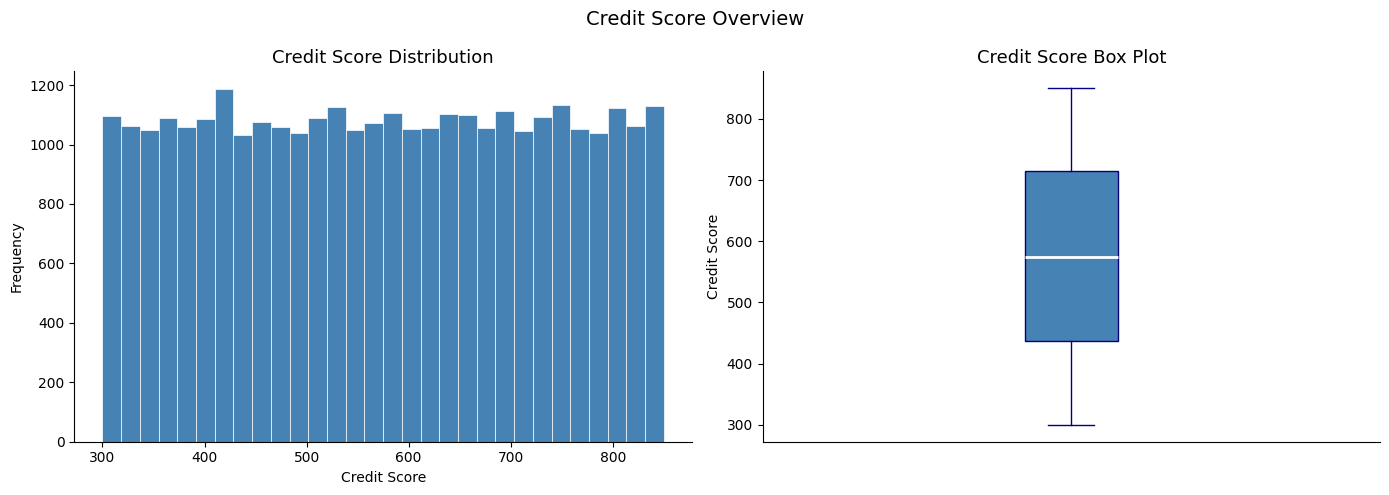

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['credit_score'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Credit Score Distribution', fontsize=13)
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(
    df['credit_score'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4)
)
axes[1].set_title('Credit Score Box Plot', fontsize=13)
axes[1].set_ylabel('Credit Score')
axes[1].set_xticks([])

plt.suptitle('Credit Score Overview', fontsize=14)
plt.tight_layout()
plt.show()

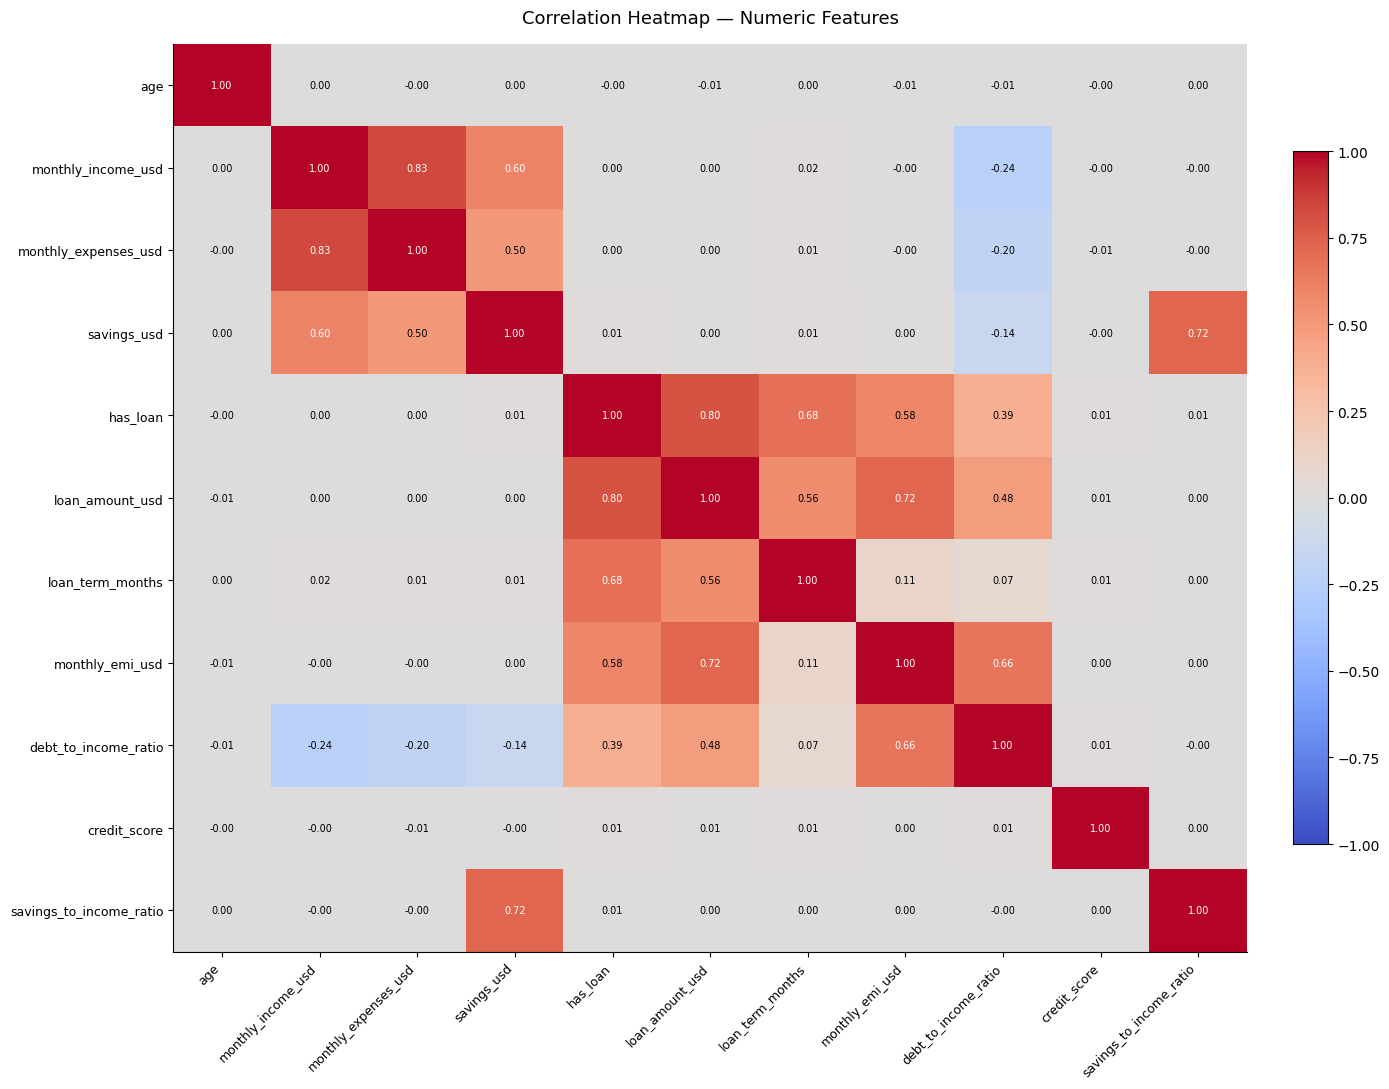

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, pad=15)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        txt_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=txt_color)

plt.tight_layout()
plt.show()

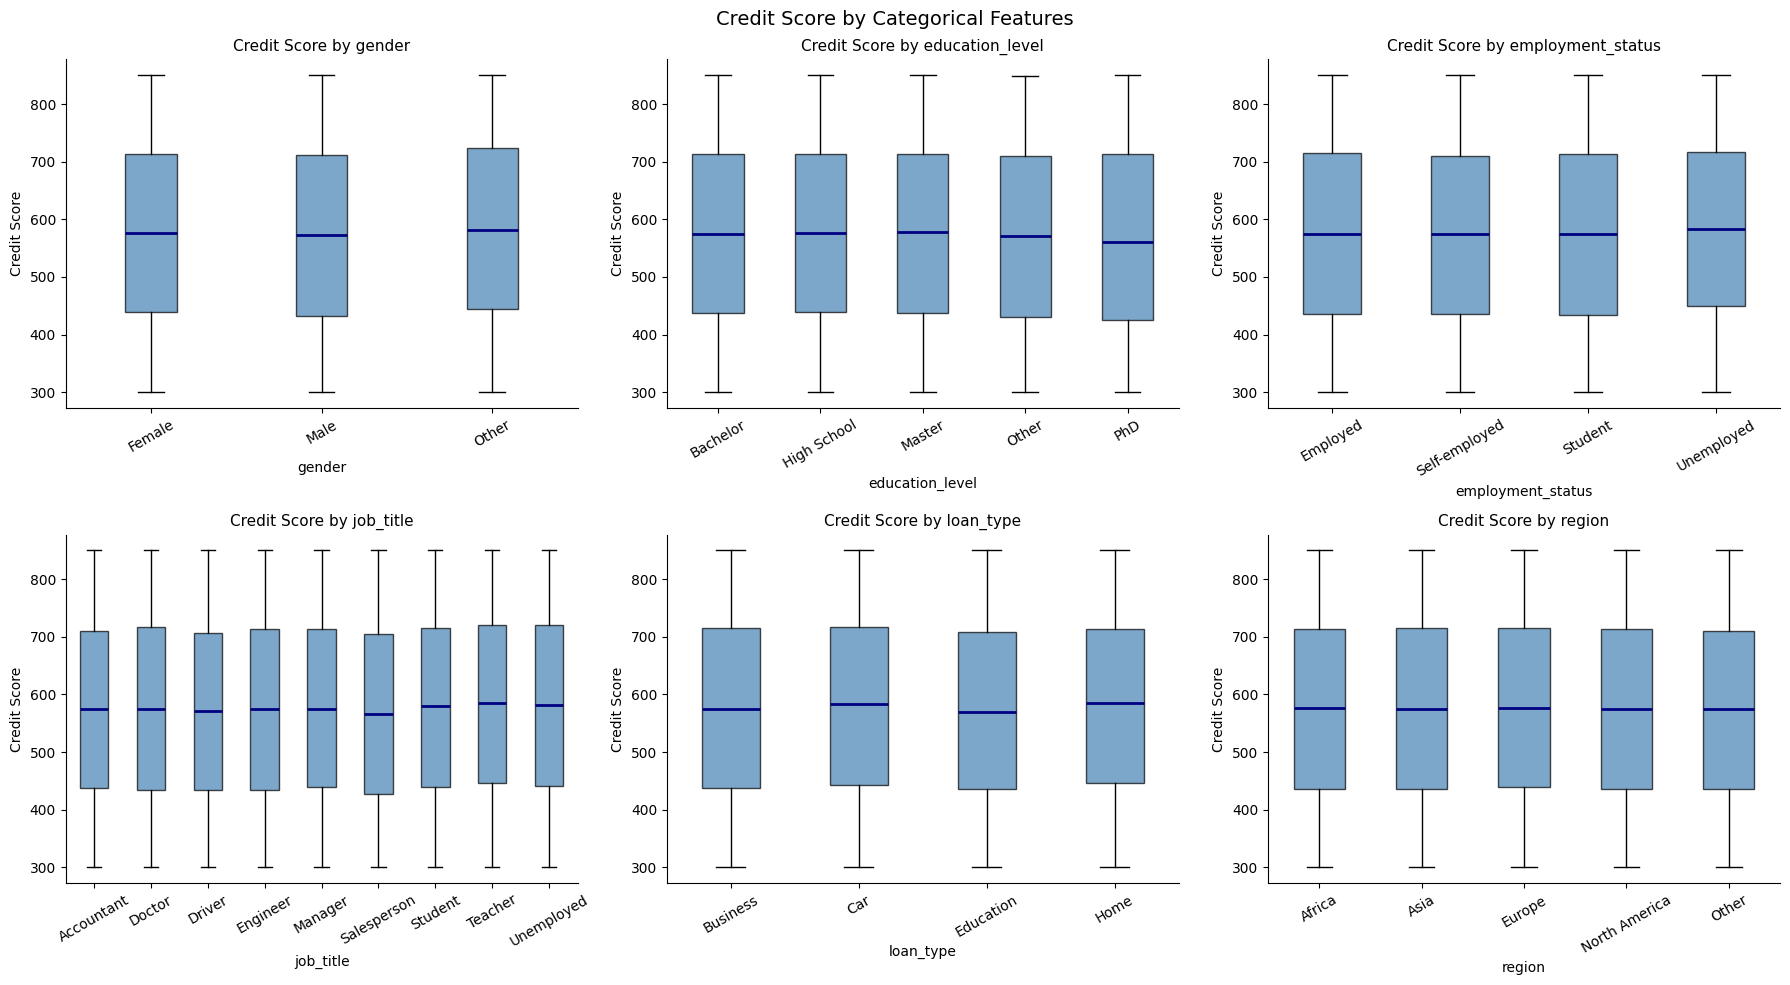

In [13]:
cat_plot_cols = ['gender', 'education_level', 'employment_status', 'job_title', 'loan_type', 'region']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), cat_plot_cols):
    categories = sorted(df[col].dropna().unique())
    data = [df[df[col] == c]['credit_score'].values for c in categories]
    ax.boxplot(
        data, labels=categories, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='navy', linewidth=2)
    )
    ax.set_title(f'Credit Score by {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Credit Score')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Credit Score by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

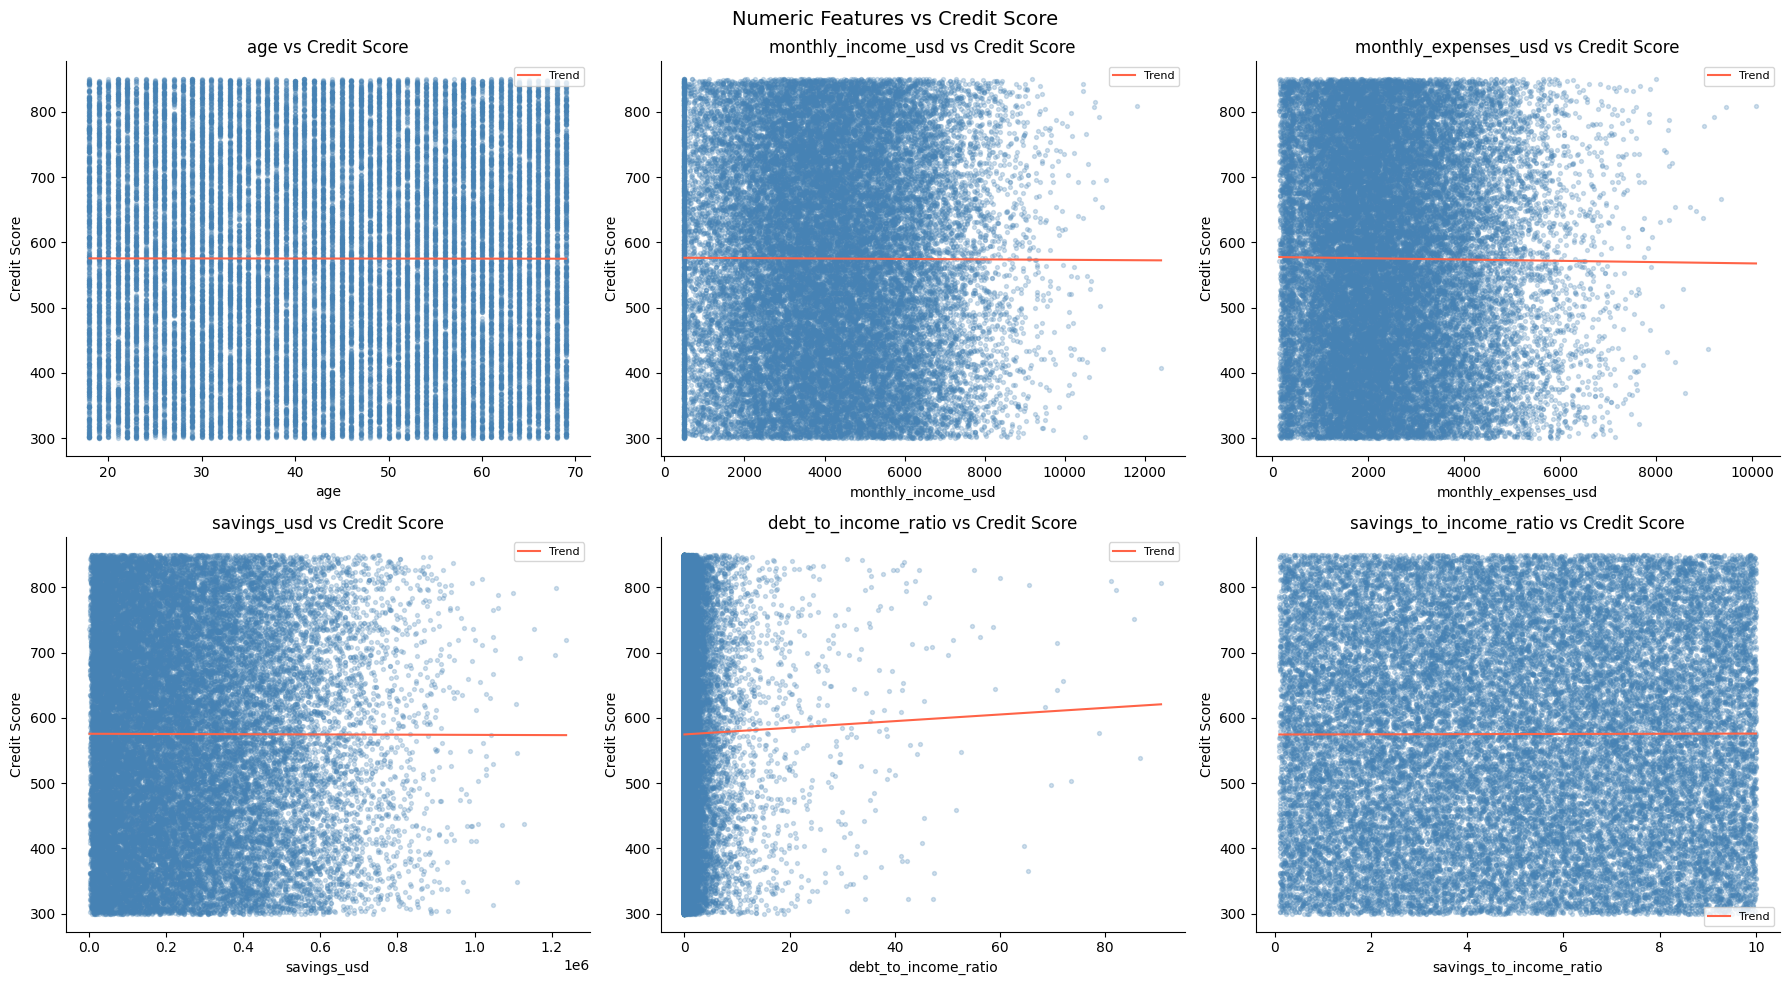

In [14]:
scatter_feats = ['age', 'monthly_income_usd', 'monthly_expenses_usd',
                 'savings_usd', 'debt_to_income_ratio', 'savings_to_income_ratio']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), scatter_feats):
    x = df[feat]
    y = df['credit_score']
    ax.scatter(x, y, alpha=0.25, s=8, color='steelblue')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, label='Trend')
    ax.set_xlabel(feat)
    ax.set_ylabel('Credit Score')
    ax.set_title(f'{feat} vs Credit Score')
    ax.legend(fontsize=8)

plt.suptitle('Numeric Features vs Credit Score', fontsize=14)
plt.tight_layout()
plt.show()

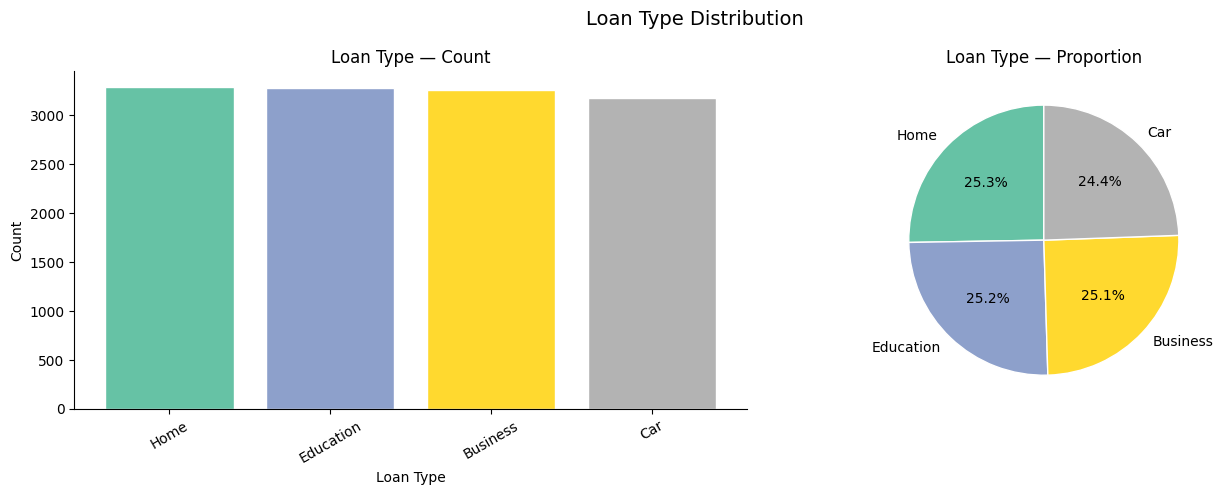

In [15]:
loan_counts = df['loan_type'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(loan_counts)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(loan_counts.index, loan_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Loan Type — Count', fontsize=12)
axes[0].set_xlabel('Loan Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(
    loan_counts.values, labels=loan_counts.index,
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(edgecolor='white')
)
axes[1].set_title('Loan Type — Proportion', fontsize=12)

plt.suptitle('Loan Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [16]:
# Extract temporal features from record_date
df['record_year'] = df['record_date'].dt.year
df['record_month'] = df['record_date'].dt.month

# Drop columns not used in modelling
df.drop(columns=['user_id', 'record_date'], inplace=True)

print(f'Shape after feature engineering: {df.shape}')
df.head()

Shape after feature engineering: (32424, 19)


,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_year,record_month
0,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,0,NaN,0.00,0,0.00,0.00,430,8.68,Other,2024,9
1,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,1,Education,146323.34,36,4953.50,1.40,543,6.16,North America,2022,2
2,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,0,NaN,0.00,0,0.00,0.00,754,6.87,Africa,2022,12
3,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,1,Business,93242.37,24,4926.57,0.84,461,4.31,Europe,2023,2
4,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,0,NaN,0.00,0,0.00,0.00,516,7.50,Africa,2021,7


In [17]:
# Fill NaN loan_type for non-borrowers so get_dummies creates a 'None' column
df['loan_type'] = df['loan_type'].fillna('None')

cat_encode = ['gender', 'education_level', 'employment_status', 'job_title', 'loan_type', 'region']
df_enc = pd.get_dummies(df, columns=cat_encode, drop_first=True)

# Ensure dummy columns are int (pandas 2.0+ returns bool by default)
bool_cols = df_enc.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f'Shape after one-hot encoding: {df_enc.shape}')
df_enc.head()

Shape after one-hot encoding: (32424, 38)


,age,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_amount_usd,loan_term_months,monthly_emi_usd,debt_to_income_ratio,credit_score,...,job_title_Teacher,job_title_Unemployed,loan_type_Car,loan_type_Education,loan_type_Home,loan_type_None,region_Asia,region_Europe,region_North America,region_Other
0,56,3531.69,1182.59,367655.03,0,0.00,0,0.00,0.00,430,...,0,0,0,0,0,1,0,0,0,1
1,19,3531.73,2367.99,260869.10,1,146323.34,36,4953.50,1.40,543,...,0,0,0,1,0,0,0,0,1,0
2,20,2799.49,1003.91,230921.21,0,0.00,0,0.00,0.00,754,...,1,0,0,0,0,1,0,0,0,0
3,25,5894.88,4440.12,304815.51,1,93242.37,24,4926.57,0.84,461,...,0,0,0,0,0,0,0,1,0,0
4,53,5128.93,4137.61,461509.48,0,0.00,0,0.00,0.00,516,...,0,0,0,0,0,1,0,0,0,0


## 7. Feature Selection

In [18]:
corr_target = (
    df_enc.corr()["credit_score"]
    .drop("credit_score")
    .sort_values(key=abs, ascending=False)
)

print("Feature correlations with credit_score:")
print(corr_target.to_string())

# NOTE: This synthetic dataset was generated without strong feature->target
# relationships (max |corr| = 0.014).  A THRESHOLD of 0.02 would drop EVERY
# feature and leave X with 0 columns — causing the scaler to crash.
# We keep all features and let Random Forest determine importance itself.
print()
print(f"Keeping all {len(corr_target)} features for modelling.")
print(f"Final shape: {df_enc.shape}")

Feature correlations with credit_score:
job_title_Teacher                  0.014418
job_title_Salesperson             -0.013906
record_month                      -0.013485
gender_Male                       -0.012899
debt_to_income_ratio               0.012049
record_year                        0.011086
employment_status_Unemployed       0.010936
education_level_PhD               -0.010394
loan_term_months                   0.010234
loan_type_Home                     0.009976
job_title_Driver                  -0.009456
gender_Other                       0.008950
has_loan                           0.008730
loan_type_None                    -0.008730
monthly_expenses_usd              -0.008588
loan_type_Car                      0.008535
job_title_Unemployed               0.007884
job_title_Student                  0.007594
loan_amount_usd                    0.007274
employment_status_Self-employed   -0.006266
region_Other                      -0.005894
job_title_Engineer                -0

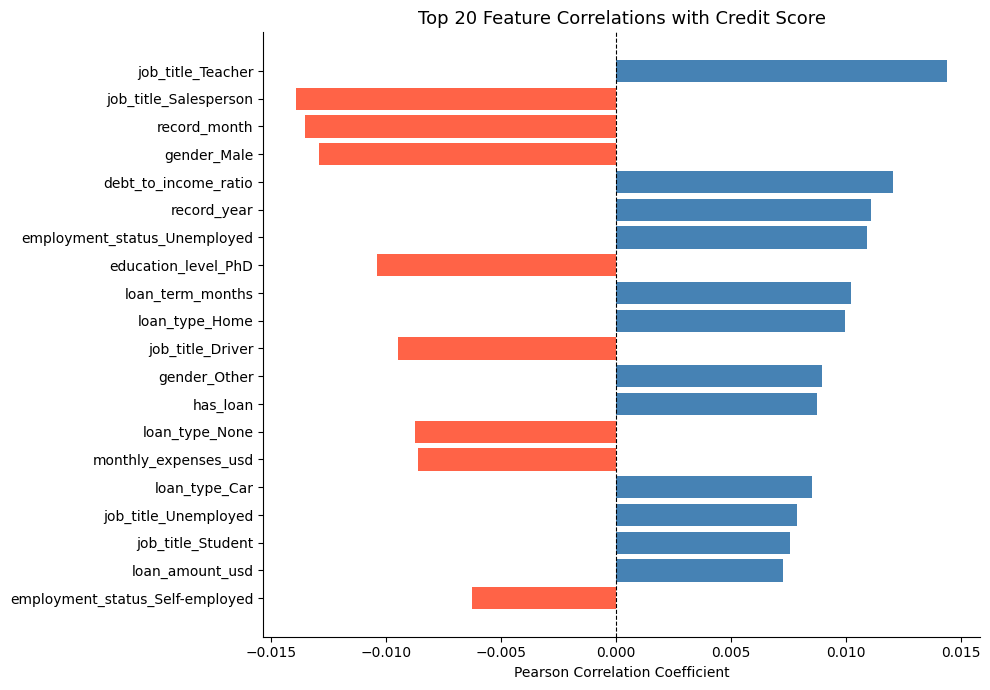

In [19]:
top_n = 20
top_corr = corr_target.head(top_n)
bar_colors = ['steelblue' if v >= 0 else 'tomato' for v in top_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=bar_colors[::-1])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Top {top_n} Feature Correlations with Credit Score', fontsize=13)
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

## 8. Train / Test Split & Scaling

In [20]:
X = df_enc.drop(columns=['credit_score'])
y = df_enc['credit_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (25939, 37)  |  X_test: (6485, 37)
y_train: (25939,)  |  y_test: (6485,)


In [21]:
# Scaling used for MLR only — GBR does not require feature scaling
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns,  index=X_test.index)
print('Scaling complete.')

Scaling complete.


## 9. Model 1 — Multiple Linear Regression

In [22]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('Multiple Linear Regression — trained.')
print(f'Intercept        : {lr.intercept_:.4f}')
print(f'Num coefficients : {len(lr.coef_)}')

Multiple Linear Regression — trained.
Intercept        : 575.1158
Num coefficients : 37


## 10. Model 2 — Gradient Boosting Regressor

In [23]:
# GBR — sequential boosting on residuals (contrast to RF parallel bagging)
# n_estimators: number of boosting stages
# learning_rate: shrinks each tree contribution (tradeoff with n_estimators)
# max_depth: shallow trees preferred for boosting
# subsample: stochastic gradient boosting (adds regularisation)
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting Regressor — trained.")
print(f"Number of estimators : {gbr.n_estimators}")
print(f"Learning rate        : {gbr.learning_rate}")
print(f"Max depth            : {gbr.max_depth}")

Gradient Boosting Regressor — trained.
Number of estimators : 200
Learning rate        : 0.1
Max depth            : 4


## 11. Evaluation Metrics

In [24]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    sep = '=' * 45
    print(sep)
    print(f'  {name}')
    print(sep)
    print(f'  MAE  : {mae:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R2   : {r2:.4f}')
    print()
    return {'Model': name, 'MAE': round(mae,4), 'MSE': round(mse,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

results = []
results.append(evaluate('Multiple Linear Regression', y_test, y_pred_lr))
results.append(evaluate('Gradient Boosting Regressor', y_test, y_pred_gbr))

pd.DataFrame(results).set_index('Model')

  Multiple Linear Regression
  MAE  : 138.8500
  MSE  : 25602.8851
  RMSE : 160.0090
  R2   : -0.0007

  Gradient Boosting Regressor
  MAE  : 139.0322
  MSE  : 25818.0764
  RMSE : 160.6800
  R2   : -0.0091



,MAE,MSE,RMSE,R2
Model,,,,
Multiple Linear Regression,138.8500,25602.8851,160.009,-0.0007
Gradient Boosting Regressor,139.0322,25818.0764,160.680,-0.0091


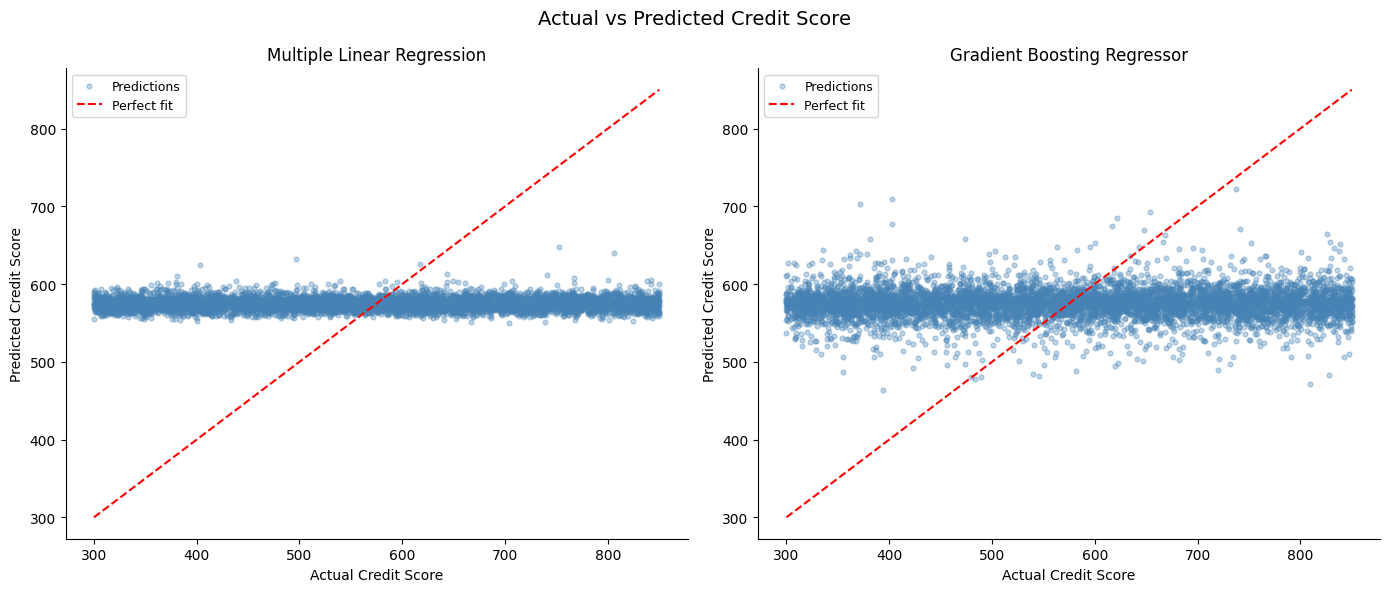

In [25]:
models_eval = [
    ('Multiple Linear Regression', y_pred_lr),
    ('Gradient Boosting Regressor', y_pred_gbr),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, y_pred) in zip(axes, models_eval):
    ax.scatter(y_test, y_pred, alpha=0.35, s=12, color='steelblue', label='Predictions')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Credit Score')
    ax.set_ylabel('Predicted Credit Score')
    ax.set_title(name)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Credit Score', fontsize=14)
plt.tight_layout()
plt.show()

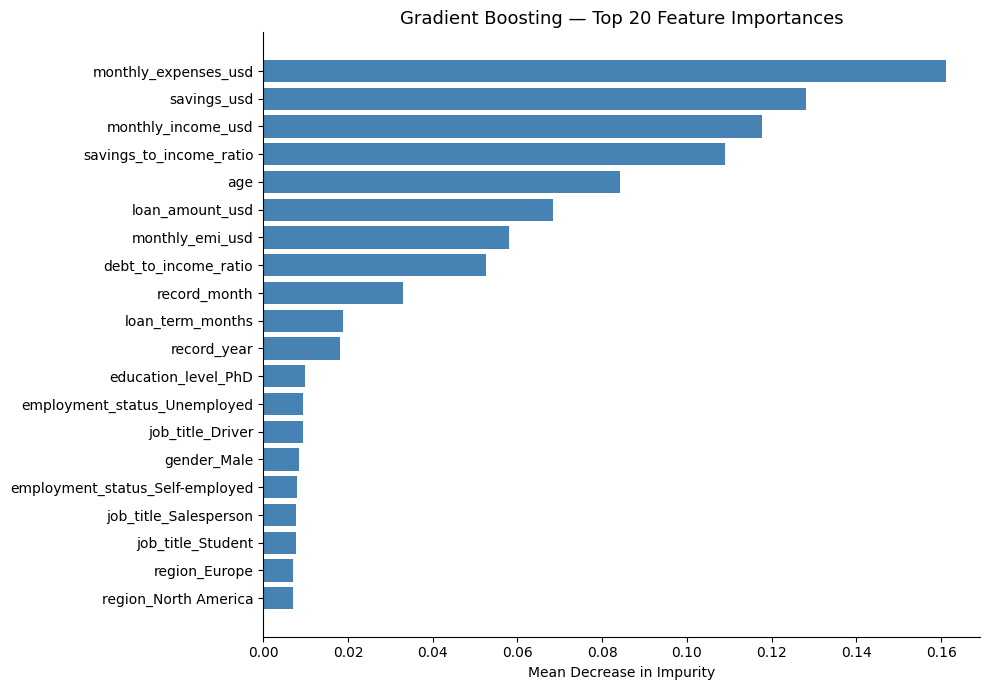

In [26]:
feat_imp = pd.Series(gbr.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue')
ax.set_title('Gradient Boosting — Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

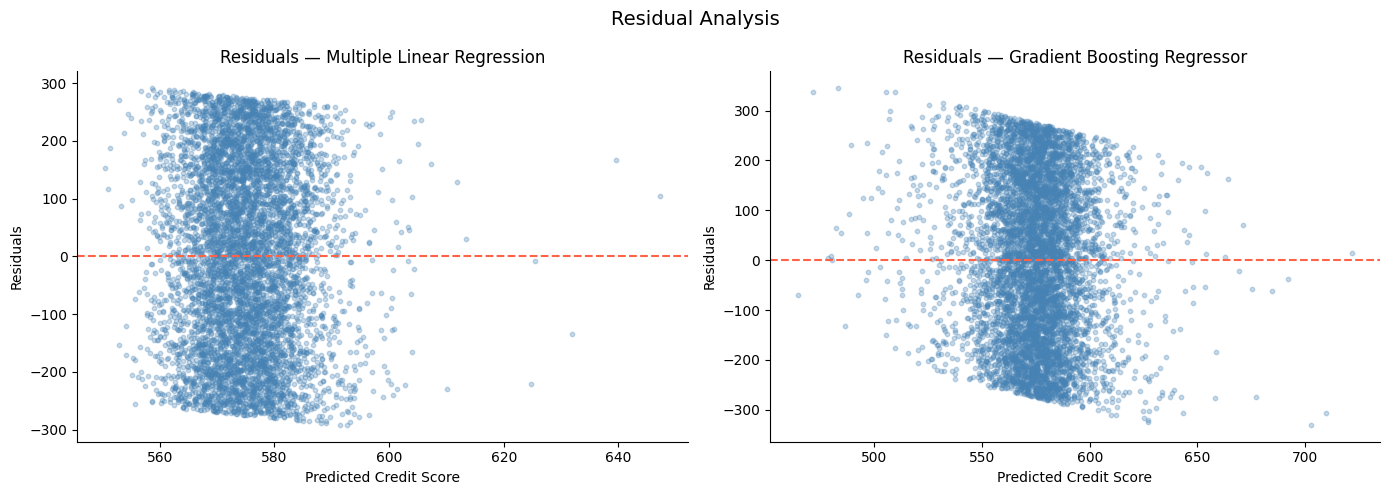

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, models_eval):
    residuals = np.array(y_test) - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
    ax.axhline(0, color='tomato', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Credit Score')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals — {name}')

plt.suptitle('Residual Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 12. Predict Credit Score — Umar's Financial Profile

In [28]:
# Umar's profile (from Bank App dummy data)
# income=5500, avg_expenses=2893, savings=13600, loan=1,200,000 (720k remaining)

umar_raw = {
    'age': 32,
    'monthly_income_usd': 5500.0,
    'monthly_expenses_usd': 2893.0,
    'savings_usd': 13600.0,
    'has_loan': 1,
    'loan_amount_usd': 1200000.0,
    'loan_term_months': 360,
    'monthly_emi_usd': 1688.0,
    'debt_to_income_ratio': round(1688.0 / 5500.0, 4),
    'savings_to_income_ratio': round(13600.0 / 5500.0, 4),
    'record_year': 2024,
    'record_month': 5,
    # One-hot fields (drop_first=True; base categories dropped)
    'gender_Male': 1,
    'gender_Other': 0,
    'education_level_High School': 0,
    'education_level_Master': 0,
    'education_level_Other': 0,
    'education_level_PhD': 0,
    'employment_status_Self-employed': 0,
    'employment_status_Student': 0,
    'employment_status_Unemployed': 0,
    'job_title_Doctor': 0,
    'job_title_Driver': 0,
    'job_title_Engineer': 0,
    'job_title_Manager': 1,
    'job_title_Salesperson': 0,
    'job_title_Student': 0,
    'job_title_Teacher': 0,
    'job_title_Unemployed': 0,
    'loan_type_Education': 0,
    'loan_type_Home': 1,
    'loan_type_None': 0,
    'region_Asia': 1,
    'region_Europe': 0,
    'region_North America': 0,
    'region_Other': 0,
}

import numpy as np
umar_df = pd.DataFrame([umar_raw]).reindex(columns=X_train.columns, fill_value=0)

raw_lr  = lr.predict(scaler.transform(umar_df))[0]
raw_gbr = gbr.predict(umar_df)[0]

score_lr  = int(round(float(np.clip(raw_lr,  300, 850))))
score_gbr = int(round(float(np.clip(raw_gbr, 300, 850))))

def rating(s):
    if s >= 750: return 'Excellent'
    if s >= 700: return 'Very Good'
    if s >= 650: return 'Good'
    if s >= 600: return 'Fair'
    if s >= 550: return 'Average'
    return 'Poor'

print("=" * 45)
print("  Umar's Predicted Credit Score")
print("=" * 45)
print(f"  Linear Regression  : {score_lr}   ({rating(score_lr)})")
print(f"  Gradient Boosting  : {score_gbr}   ({rating(score_gbr)})")
print()
print(f"  Final score (GBR)  : {score_gbr} / 850")

  Umar's Predicted Credit Score
  Linear Regression  : 581   (Average)
  Gradient Boosting  : 603   (Fair)

  Final score (GBR)  : 603 / 850
